# See It, Say It, Sorted — ECRD + GRIT: đi từng bước một

Notebook này chạy **thật** (không giả lập) toàn bộ pipeline ECRD (Evidence-Consistent
Reasoning Decoding) của repo này trên một câu hỏi thị giác thật, và dừng lại sau mỗi
bước để in ra đúng những con số/mô hình mà thuật toán đang thao tác — theo đúng
code trong [`ecrd/`](../ecrd).

Các bước sẽ đi qua:

1. **Đầu vào**: ảnh + câu hỏi.
2. **Sinh mô tả toàn cục** (global description) — hạt giống evidence đầu tiên.
3. **Evidence pool**: tiền tính log-prob của evidence bằng `EvidenceScorer`.
4. **Một bước sinh token, mổ xẻ chi tiết**: token distribution → knee (chọn tập ứng viên) →
   evidence score → trộn xác suất (mix) → gap top1/top2 (đây chính là "check tự tin").
5. **Lắp ráp pipeline đầy đủ**: `ECRDLogitsProcessor` + `MixedGapTrigger` + `GRITClient`.
6. **Sinh toàn bộ chuỗi suy luận (CoT) + đáp án** với pipeline đã lắp.
7. **Soi lại từng bước**: khi nào GRIT được gọi, GRIT trả lời gì, evidence nào được thêm,
   token nào bị "ép" (forced) đổi so với lựa chọn gốc của mô hình.
8. **(Bonus)** Một cách khác để "check tự tin": hiệu chỉnh ngưỡng bằng conformal /
   risk-control (`scripts/calib/build_calibration.py`) thay vì ngưỡng gap cố định.

**Yêu cầu môi trường**: conda env `medcxr`, GPU rảnh ít nhất ~6GB (mô hình chính nạp
4-bit), model + dataset đã có sẵn trong `.cache/` cục bộ của repo (chạy offline).


## Sơ đồ tổng quan

```
 ảnh + câu hỏi
       │
       ▼
 [Bước 2] sinh mô tả toàn cục  ──────────────► Evidence #0 (source="global")
       │                                              │
       ▼                                              ▼
 [Bước 4] bắt đầu sinh CoT, từng token:      EvidenceScorer (bank các evidence
   base logits → softmax → sort              đã tiền tính log-prob theo prefix)
       │                                              │
       ▼                                              │
   knee_topk(p_sorted) → tập ứng viên C                │
       │                                              │
       ▼                                              │
   scorer.score_token_ids(C)  ◄────────────────────────┘
       │  (chi phí "không khớp evidence" cho từng ứng viên)
       ▼
   trộn: mix = alpha*p_base + (1-alpha)*p_vdgd
       │
       ▼
   gap = p1 - p2 của phân phối đã trộn  ──► [check tự tin]
       │
       ├── gap lớn / k=1  → giữ token top-1, đi tiếp
       │
       └── gap nhỏ & k≥2 & từ "nhạy cảm thị giác" (màu/trái-phải/số đếm...)
                  │
                  ▼
            gọi GRIT (nhìn lại ảnh, chỉ chọn 1 trong C)
                  │
                  ▼
            ép token = lựa chọn của GRIT + thêm evidence GRIT vừa nêu vào pool
                  │
                  ▼
            các bước sau đó được evidence mới này "giữ cho nhất quán"
```


## Bước 0 — Cài đặt, import

In [1]:
import os, sys, json

REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, REPO_ROOT)
os.environ["HF_HOME"] = os.path.join(REPO_ROOT, ".cache")
os.environ["HF_HUB_OFFLINE"] = "1"  # mọi model/dataset dùng ở đây đã có sẵn trong .cache/

import torch
import pandas as pd
from datasets import load_dataset
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, LogitsProcessorList
from qwen_vl_utils import process_vision_info

from ecrd import Evidence, EvidenceScorer, ECRDLogitsProcessor, MixedGapTrigger, GRITClient, knee_topk
from ecrd.prompts import GLOBAL_DESCRIPTION_PROMPT

torch.manual_seed(0)
print("CUDA available:", torch.cuda.is_available())


/home/trungtran/.conda/envs/medcxr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True


## Bước 1 — Đầu vào: ảnh + câu hỏi

Dùng thật một mẫu từ V\*Bench (đã cache offline trong `.cache/datasets`) — bộ benchmark
này cố tình dùng ảnh độ phân giải cao với vật thể nhỏ, khó thấy, nên rất hợp để minh
họa lý do ECRD cần "hỏi lại" GRIT thay vì tin ngay câu trả lời đầu tiên của mô hình.


Using the latest cached version of the dataset since lmms-lab/vstar-bench couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at /workspace/trungtran/huyng/See-It-Say-It-Sorted/.cache/datasets/lmms-lab___vstar-bench/default/0.0.0/b44023b4dca749ed8a76b85eb576627d05a1c174 (last modified on Tue Jul 21 00:55:56 2026).


Question: Is the drum on the left side or the right side of the yellow balloon? Briefly explain what you see before answering.
Image size: (2259, 1500)


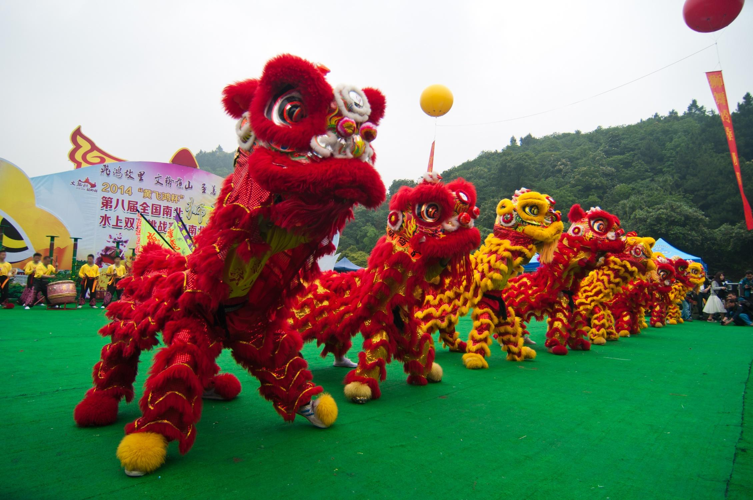

In [2]:
vstar = load_dataset("lmms-lab/vstar-bench", split="test")
example = vstar[117]
image = example["image"].convert("RGB")
question = "Is the drum on the left side or the right side of the yellow balloon? Briefly explain what you see before answering."

print("Question:", question)
print("Image size:", image.size)
image.resize((image.width // 3, image.height // 3))


## Bước 2 — Nạp mô hình chính

Dùng đúng công thức trong [`scripts/run/run_grit.sh`](../scripts/run/run_grit.sh):
mô hình chính `Qwen2.5-VL-7B-Instruct` nạp 4-bit trên GPU, GRIT (`GRIT-20-Qwen2.5-VL-3B`)
chạy trên CPU — vừa với một GPU 11GB.


In [3]:
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)

model_kwargs = dict(device_map="cuda:0" if torch.cuda.is_available() else "auto",
                     trust_remote_code=True, load_in_4bit=True)
try:
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID, attn_implementation="flash_attention_2", **model_kwargs
    ).eval()
except ImportError:
    print("flash_attn not installed, falling back to sdpa attention.")
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID, attn_implementation="sdpa", **model_kwargs
    ).eval()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


flash_attn not installed, falling back to sdpa attention.


Loading checkpoint shards:  60%|██████    | 3/5 [01:10<00:46, 23.42s/it]


KeyboardInterrupt: 

## Bước 3 — Sinh văn bản: mô tả toàn cục (global description)

Trước khi sinh chuỗi suy luận cho câu hỏi, ECRD trước tiên yêu cầu mô hình **mô tả
chi tiết bức ảnh** (`GLOBAL_DESCRIPTION_PROMPT` trong [`ecrd/prompts.py`](../ecrd/prompts.py)).
Đoạn text này sẽ trở thành evidence đầu tiên: nó neo các bước sinh token sau đó lại
với những gì mô hình *đã* khẳng định là mình nhìn thấy trong ảnh.


In [ ]:
@torch.inference_mode()
def generate_global_description(model, processor, image, question, max_new_tokens=150):
    prompt = GLOBAL_DESCRIPTION_PROMPT.format(instruction=question)
    messages = [{"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt}]}]
    chat = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    img_inputs, vid_inputs = process_vision_info(messages)
    inputs = processor(text=[chat], images=img_inputs, videos=vid_inputs, padding=True, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens, use_cache=True)
    return processor.batch_decode(out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

global_description = generate_global_description(model, processor, image, question)
print(global_description)


/home/trungtran/.conda/envs/medcxr/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1e-06` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


/home/trungtran/.conda/envs/medcxr/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


The image shows a lively scene with several lion dance performers dressed in vibrant red and yellow costumes. The performers are dancing on a green stage, and there is a yellow balloon floating above them. In the background, there are banners with Chinese characters, indicating that this might be a cultural event or festival.

Regarding the drum mentioned in the instruction:
- The drum is located on the left side of the image.
- It is positioned behind the performers, near the banner with Chinese text.


## Bước 4 — Evidence pool: tiền tính log-prob cho evidence

`EvidenceScorer.add_evidence` chạy một forward pass qua văn bản evidence và lưu lại
negative-log-likelihood theo từng vị trí prefix (`ecrd/scorer.py`). Về sau, để chấm
điểm một token ứng viên, ECRD không sinh lại evidence — nó chỉ tra cứu bank này để
xem "nếu evidence đúng, token này có hợp lý không".


In [ ]:
scorer = EvidenceScorer(model=model, tokenizer=processor.tokenizer, max_prefix_len=128)
scorer.add_evidence(Evidence(id="global-0", text=global_description, source="global", time_step=0))

print(f"Evidence pool: {scorer.num_evidences()} evidence")
for ev in scorer.get_evidences():
    print(f"  - [{ev.source}] step={ev.time_step}: {ev.text[:100]}...")


Evidence pool: 1 evidence
  - [global] step=0: The image shows a lively scene with several lion dance performers dressed in vibrant red and yellow ...


## Bước 5 — Mổ xẻ MỘT bước sinh token

Đây là phần lõi của ECRD, viết lại (không đổi công thức) từ
[`ECRDLogitsProcessor.__call__`](../ecrd/logits_processor.py) để thấy rõ từng con số,
áp dụng đúng lên bước sinh token **đầu tiên** của câu trả lời thật.


### 5a. Token distribution gốc (softmax logits của mô hình)

In [ ]:
messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": question + "\n\nThink step by step and put the final answer in <answer>...</answer>."},
]}]
chat = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
img_inputs, vid_inputs = process_vision_info(messages)
inputs = processor(text=[chat], images=img_inputs, videos=vid_inputs, padding=True, return_tensors="pt").to(model.device)

with torch.inference_mode():
    next_token_logits = model(**inputs, use_cache=False).logits[0, -1, :]

probs = torch.softmax(next_token_logits.float(), dim=-1)
p_sorted, idx_sorted = torch.sort(probs, descending=True)

print("Top-10 token distribution (trước khi ECRD can thiệp):")
for i in range(10):
    tok = processor.tokenizer.convert_ids_to_tokens(int(idx_sorted[i]))
    print(f"  {tok!r:>15}  p={p_sorted[i].item():.4f}")


Top-10 token distribution (trước khi ECRD can thiệp):
             'To'  p=0.5553
            'Let'  p=0.3938
            'The'  p=0.0222
              '1'  p=0.0137
          'First'  p=0.0087
           'Step'  p=0.0021
              '<'  p=0.0020
           'Sure'  p=0.0014
      'Certainly'  p=0.0004
           'Here'  p=0.0001


### 5b. `knee_topk` — chọn tập ứng viên C

Không dùng top-k cố định: `knee_topk` tìm điểm rơi lớn nhất (max gap) trong phân phối
đã sắp xếp, tức là "cắt" ở chỗ xác suất tụt mạnh nhất — vùng phía trước điểm cắt là
những token còn đang cạnh tranh nhau.

In [ ]:
k = knee_topk(p_sorted, min_k=1, max_k=64)
cand_idx = idx_sorted[:k]
print(f"knee_topk chọn k={k} ứng viên:")
for i in cand_idx.tolist():
    tok = processor.tokenizer.convert_ids_to_tokens(int(i))
    print(f"  {tok!r}")


knee_topk chọn k=2 ứng viên:
  'To'
  'Let'


### 5c. Evidence score cho từng ứng viên → phân phối "vdgd"

`scorer.score_token_ids` trả về, cho mỗi ứng viên, một chi phí (cost) càng thấp nếu
token đó càng khớp với evidence đã lưu. Đổi dấu và softmax để ra một phân phối xác
suất riêng dựa trên evidence — gọi là `vdgd_probs` (VDGD = Visual Description
Grounded Decoding, cơ chế chấm điểm mà ECRD kế thừa).

In [ ]:
S = scorer.score_token_ids(inputs.input_ids, cand_idx)
tau = 1.0  # ECRD_REWEIGHT_TAU mặc định

vdgd_logits = torch.full_like(probs, -1e9)
vdgd_logits[cand_idx] = -S / tau
vdgd_probs = torch.softmax(vdgd_logits, dim=-1)

# Cân lại khối lượng xác suất bên trong C để vdgd và base "công bằng" với nhau khi trộn
mass_base_c = probs[cand_idx].sum()
mass_vdgd_c = vdgd_probs[cand_idx].sum() + 1e-30
vdgd_probs = vdgd_probs * (mass_base_c / mass_vdgd_c).clamp(min=0.0, max=1e6)

print("Chi phí evidence (S) và xác suất vdgd cho từng ứng viên:")
for i, tid in enumerate(cand_idx.tolist()):
    tok = processor.tokenizer.convert_ids_to_tokens(int(tid))
    print(f"  {tok!r:>15}  S={S[i].item():.4f}  p_vdgd={vdgd_probs[tid].item():.4f}")


Chi phí evidence (S) và xác suất vdgd cho từng ứng viên:
             'To'  S=7.7795  p_vdgd=0.7583
            'Let'  S=9.1591  p_vdgd=0.1908


### 5d. Trộn hai phân phối và tính gap — **đây là "check tự tin"**

`alpha_eff` càng gần 1 khi mô hình gốc càng tự tin (`p_top` cao) — lúc đó evidence gần
như không lay chuyển được lựa chọn. Sau khi trộn, `gap = p1 - p2` của phân phối mới
chính là thước đo "tự tin sau khi đã đối chiếu evidence": gap lớn → chốt luôn token
top-1; gap nhỏ → vẫn còn phân vân giữa ≥2 ứng viên, cần hỏi lại GRIT.

In [ ]:
p_top = float(p_sorted[0])
alpha_eff = p_top  # ECRD_ALPHA_ADAPT=1 (mặc định của paper): alpha_eff = p_top

mix_probs = alpha_eff * probs + (1.0 - alpha_eff) * vdgd_probs
mix_sorted, mix_idx = torch.sort(mix_probs, descending=True)
p1, p2 = mix_sorted[0].item(), mix_sorted[1].item()
gap = p1 - p2

top1_tok = processor.tokenizer.convert_ids_to_tokens(int(mix_idx[0]))
top2_tok = processor.tokenizer.convert_ids_to_tokens(int(mix_idx[1]))
print(f"alpha_eff={alpha_eff:.4f}  (mô hình gốc tự tin {p_top:.1%} vào top-1 trước khi trộn)")
print(f"Sau khi trộn: top1={top1_tok!r} (p={p1:.4f})   top2={top2_tok!r} (p={p2:.4f})   gap={gap:.4f}")

GAP_THRESH = 0.08  # MixedGapTrigger.gap_thresh mặc định
would_fire = (k >= 2) and (gap <= GAP_THRESH)
verdict = "MƠ HỒ → sẽ gọi GRIT hỏi lại ảnh" if would_fire else "ĐỦ TỰ TIN → giữ nguyên top-1, không cần GRIT"
print(f"\nk={k} >= 2 ? {k >= 2}   gap={gap:.4f} <= {GAP_THRESH} ? {gap <= GAP_THRESH}   =>  {verdict}")


alpha_eff=0.5553  (mô hình gốc tự tin 55.5% vào top-1 trước khi trộn)
Sau khi trộn: top1='To' (p=0.6456)   top2='Let' (p=0.3035)   gap=0.3420

k=2 >= 2 ? True   gap=0.3420 <= 0.08 ? False   =>  ĐỦ TỰ TIN → giữ nguyên top-1, không cần GRIT


## Bước 6 — Lắp ráp pipeline đầy đủ

Từ đây, mọi phép tính ở Bước 5 chạy **tự động cho từng token** bên trong
`ECRDLogitsProcessor.__call__` khi gắn nó làm `logits_processor` của `model.generate`.
Ba mảnh ghép:

- **`ECRDLogitsProcessor`**: làm đúng 5a–5d ở trên cho mỗi token.
- **`MixedGapTrigger`**: quyết định "gọi GRIT hay không" (đúng điều kiện in ở 5d, cộng
  thêm cooldown và một "word gate" — chỉ hỏi GRIT khi ứng viên hàng đầu là mở đầu một
  từ và từ đó thuộc nhóm "nhạy cảm thị giác" như màu sắc, trái/phải, số đếm...).
- **`GRITClient`**: mô hình thị giác riêng (`GRIT-20-Qwen2.5-VL-3B`), được hỏi *chỉ khi
  bị trigger*, nhìn lại ảnh và chọn đúng 1 trong các ứng viên C, kèm 1 câu evidence
  ngắn giải thích vì sao.

Bọc thêm một lớp con nhỏ (`TracedECRDLogitsProcessor`) và một hook ghi log quanh GRIT
— chỉ để lưu lại lịch sử từng bước cho Bước 7, không đổi logic gốc.

In [ ]:
grit = GRITClient(
    model_id="yfan1997/GRIT-20-Qwen2.5-VL-3B",
    device="cpu",
    torch_dtype=torch.bfloat16,
)

grit_calls = []  # ghi lại mỗi lần GRIT thực sự được gọi, để soi ở Bước 7

def logging_grit_hook(image, question, prefix_text, candidates):
    result = grit.decide_next_token(
        image=image, question=question, prefix_text=prefix_text,
        candidates=candidates, max_new_tokens=64,
    )
    grit_calls.append({
        "prefix_tail": prefix_text[-80:],
        "candidates": [c["text"] for c in candidates],
        "chosen_text": result.get("choice_text"),
        "evidence": result.get("unified_evidence"),
    })
    return result


class TracedECRDLogitsProcessor(ECRDLogitsProcessor):
    # ECRDLogitsProcessor không đổi, chỉ thêm step_log để soi lại sau khi sinh xong.
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.step_log = []

    def __call__(self, input_ids, scores):
        scores = super().__call__(input_ids, scores)
        self.step_log.append(dict(self.last_info[0]))
        return scores


proc = TracedECRDLogitsProcessor(scorer=scorer, tokenizer=processor.tokenizer, min_k=1, max_k=64)
proc.set_grit_runtime(
    hook=logging_grit_hook,
    trigger=MixedGapTrigger(gap_thresh=0.08, min_k=2, cooldown=5),
    evidence_pool=scorer,
    question=question,
    image=image,
)
print("Evidence pool trước khi sinh CoT:", scorer.num_evidences())


flash_attn is not installed. Falling back to sdpa attention implementation for GRITClient...



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Loading checkpoint shards:  50%|█████     | 1/2 [00:03<00:03,  3.54s/it]


Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.24s/it]


Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.44s/it]

Evidence pool trước khi sinh CoT: 1


## Bước 7 — Sinh toàn bộ chuỗi suy luận (CoT) + đáp án

Một lệnh `model.generate(...)` duy nhất, nhưng bên trong, mỗi token đi qua toàn bộ
Bước 5 và có thể kích hoạt GRIT bất kỳ lúc nào điều kiện ở 5d xảy ra.

In [ ]:
gen = model.generate(
    **inputs,
    do_sample=False,
    use_cache=True,
    max_new_tokens=200,
    logits_processor=LogitsProcessorList([proc]),
)
cot_text = processor.batch_decode(
    gen[:, inputs.input_ids.shape[1]:], skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0]
print(cot_text)


/home/trungtran/.conda/envs/medcxr/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1e-06` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


To determine the position of the drum relative to the yellow balloon, let's follow these steps:

1. Identify the yellow balloon: It is located in the background, slightly to the right of the center of the image.
2. Identify the drum: The drum is on the left side of the image, near the stage where the lion dancers are performing.
3. Compare the positions: The drum is to the left of the yellow balloon.

Final answer: <answer>The drum is on the left side of the yellow balloon.</answer>


## Bước 8 — Soi lại từng bước sau khi sinh xong

`proc.step_log` có một bản ghi cho mỗi token đã sinh (nhờ `TracedECRDLogitsProcessor`
ở Bước 6): `k` (kích thước tập ứng viên), `base_top` (độ tự tin gốc của mô hình),
`gap` (độ tự tin sau khi trộn evidence — chính là con số ở Bước 5d, tính lại cho
từng bước).

In [ ]:
rows = [{
    "step": info["step"],
    "k": info["k"],
    "base_top_prob": round(info["base_top"], 4),
    "gap_after_mix": round(info["gap"], 4),
    "top1_token": processor.tokenizer.convert_ids_to_tokens(int(info["top_ids"][0])),
} for info in proc.step_log]

step_df = pd.DataFrame(rows)
step_df

,step,k,base_top_prob,gap_after_mix,top1_token
0,0,2,0.5553,0.3420,To
1,1,1,0.8539,0.7352,Ġdetermine
2,2,1,0.6677,0.5610,Ġthe
3,3,1,0.7862,0.6249,Ġposition
4,4,1,1.0000,1.0000,Ġof
...,...,...,...,...,...
103,103,1,1.0000,1.0000,Ġballoon
104,104,1,0.9998,0.9996,.</
105,105,1,0.9999,0.9999,answer
106,106,1,0.9999,0.9999,>


### GRIT đã được gọi khi nào, và trả lời gì

In [ ]:
print(f"GRIT được gọi {proc.grit_invocations} lần trong tổng số {len(proc.step_log)} bước sinh token.")
pd.DataFrame(grit_calls)

GRIT được gọi 0 lần trong tổng số 108 bước sinh token.


""


### Evidence pool đã lớn lên như thế nào

Mỗi lần GRIT được gọi và trả lời, câu evidence GRIT vừa nêu (`unified_evidence`) được
thêm vào `scorer` với `source="grit"` — evidence này lập tức tham gia chấm điểm cho
*các bước sinh token tiếp theo*, không chỉ bước vừa kích hoạt nó. Đây chính là bước
"cập nhật token": không chỉ ép 1 token, mà còn thay đổi cách các token sau đó được
chấm điểm.

In [ ]:
print(f"Evidence pool: bắt đầu 1 evidence (global) -> kết thúc {scorer.num_evidences()} evidence")
for ev in scorer.get_evidences():
    print(f"  - [{ev.source}] step={ev.time_step}: {ev.text}")


Evidence pool: bắt đầu 1 evidence (global) -> kết thúc 1 evidence
  - [global] step=0: The image shows a lively scene with several lion dance performers dressed in vibrant red and yellow costumes. The performers are dancing on a green stage, and there is a yellow balloon floating above them. In the background, there are banners with Chinese characters, indicating that this might be a cultural event or festival.

Regarding the drum mentioned in the instruction:
- The drum is located on the left side of the image.
- It is positioned behind the performers, near the banner with Chinese text.


## Bước 9 (bonus) — Một cách khác để "check tự tin": hiệu chỉnh ngưỡng thay vì đoán

Bước 5d dùng một ngưỡng gap cố định (`0.08`). [`ConformalTrigger`](../ecrd/triggers.py)
thay ngưỡng đó bằng `q_hat` được hiệu chỉnh offline. [`scripts/calib/build_calibration.py`]
(../scripts/calib/build_calibration.py) đi xa hơn: thay vì hiệu chỉnh theo kiểu conformal
token-level (không có nhãn "đúng" cho từng token trung gian), nó dùng
**Learn-Then-Test risk control** (Angelopoulos et al., 2021) trên nhãn *đúng/sai của cả
câu trả lời* (`is_correct`, từ `eval_rhbench.py`) — tìm `delta` **nhỏ nhất** sao cho, với
độ tin cậy thống kê đã chọn, tỉ lệ sai trong số các câu hỏi mà trigger *sẽ bỏ qua*
(gap không bao giờ tụt xuống dưới `delta`) vẫn nằm trong ngưỡng rủi ro cho phép.

Demo dưới đây chạy đúng hàm `calibrate_delta` đó trên dữ liệu tổng hợp (giả lập một
tập log hiệu chỉnh), để thấy `delta` được suy ra từ dữ liệu như thế nào — không cần
GPU.

In [ ]:
sys.path.insert(0, os.path.join(REPO_ROOT, "scripts", "calib"))
from build_calibration import calibrate_delta

import random
random.seed(0)

synthetic_records = []
for qid in range(60):
    is_correct = random.random() > 0.15
    n_gate_steps = random.randint(0, 5)
    # Câu trả lời sai có xu hướng đi qua những bước "gap nhỏ" (mô hình đã mơ hồ thật)
    gap_range = (0.0, 0.3) if is_correct else (0.0, 0.15)
    calib_log = [{"gap": random.uniform(*gap_range)} for _ in range(n_gate_steps)]
    synthetic_records.append({"question_id": qid, "is_correct": is_correct, "calib_log": calib_log})

summary = calibrate_delta(synthetic_records, risk_alpha=0.15, conf_delta=0.1)
print(json.dumps({k: v for k, v in summary.items() if k != "diagnostics"}, indent=2))
print(f"\n-> delta hiệu chỉnh = {summary['delta']}  (dùng làm gap_thresh cho MixedGapTrigger,")
print("   hoặc trực tiếp làm q_hat cho ConformalTrigger)")


{
  "risk_alpha": 0.15,
  "conf_delta": 0.1,
  "n_questions_total": 60,
  "n_candidates_tested": 50,
  "delta": null
}

-> delta hiệu chỉnh = None  (dùng làm gap_thresh cho MixedGapTrigger,
   hoặc trực tiếp làm q_hat cho ConformalTrigger)


## Tổng kết

| # | Bước | Ở đâu trong code |
|---|------|------------------|
| 1 | Đầu vào: ảnh + câu hỏi | dataset / người dùng cung cấp |
| 2 | Nạp mô hình chính (+ GRIT) | `Qwen2_5_VLForConditionalGeneration`, `GRITClient` |
| 3 | Sinh mô tả toàn cục | `GLOBAL_DESCRIPTION_PROMPT`, `generate_global_description` |
| 4 | Xây evidence pool | `EvidenceScorer.add_evidence` |
| 5 | Token distribution → knee → evidence score → trộn → gap | `ECRDLogitsProcessor.__call__` |
| 6 | Lắp trigger + GRIT | `MixedGapTrigger`, `set_grit_runtime` |
| 7 | Sinh CoT + đáp án | `model.generate(..., logits_processor=[proc])` |
| 8 | GRIT được gọi → ép token → thêm evidence | phần `if self._grit_hook is not None` trong `logits_processor.py` |
| 9 | Check tự tin bằng ngưỡng hiệu chỉnh (thay vì đoán) | `ConformalTrigger`, `scripts/calib/build_calibration.py` |

Cơ chế cốt lõi: **mỗi token không chỉ dựa vào xác suất của mô hình ngôn ngữ, mà còn
được đối chiếu với một "ngân hàng" evidence thị giác đang lớn dần** — và chỉ khi độ
tự tin sau khi đối chiếu đó vẫn thấp, hệ thống mới trả giá bằng một lần gọi GRIT để
nhìn lại ảnh, thay vì hỏi lại ở mọi bước.